<a href="https://colab.research.google.com/github/jarrodsb/ETAMU-binary-systems/blob/main/notebooks/Example_Planet_Packing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Planet Packing

## Jarrod Bieber
## East Texas A&M University
## Summer 2026
---

In [1]:
!pip install rebound

In [36]:
import rebound
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.gridspec import GridSpec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

## Lagrange Points and the Hill Radius
---

## Define the Pseudopotential (U) and Zero Velocity Contours (ZVC)

The following code defines two functions. The `pseudo_pot` function calculates the pseudopotential (`U`) for a given point (`x`, `y`) and mass ratio (`mu`) in a rotating coordinate system, often used in restricted three-body problems to describe the effective potential. The `calc_ZVC` function calculates the Zero Velocity Contour (ZVC) constant based on the mass ratio (mu) and the semimajor axis ratio (`rho`). These contours represent regions where a test particle cannot enter, defining stable or unstable regions around the primary bodies.

In [3]:
def pseudo_pot(x,y,mu):
	sign = 1
	if mu >= 0.5:
		sign = -1 #flip the sign to maintain orientation
	ro = np.sqrt((x+sign*mu)**2+y**2)
	r1 = np.sqrt((x-sign*(1.-mu))**2+y**2)
	U = (1.-mu)/ro + mu/r1 + (x**2+y**2)/2.
	return 2.*U

def calc_ZVC(rho):
	CK = mu + 2.*mu*rho  + (1.-mu)/rho + 2.*mu/(1.+rho) + 2.*np.sqrt(rho*(1.-mu)) + mu*(1.-mu)
	return CK

## Parameters of Sun-Jupiter System

The following code initializes parameters for a celestial system, likely related to a restricted three-body problem. It sets the mass ratio (`mu`), calculates the complementary mass ratio (`alpha`), and defines a semimajor axis ratio (`rho`). It then calls the `calc_ZVC` function to compute the Zero Velocity Contour constant (`C1`). Finally, it calculates the positions of the Lagrange points `L1` and `L3`, which are specific equilibrium points in the system. The calculation for `L1` and `L3` varies depending on whether the mass ratio `mu` is less than or equal to 0.5.

In [4]:
mu = 0.999 # mass ratio
alpha = 1 - mu
rho = 0.0329 # semimajor axis ratio
C1 = calc_ZVC(rho)

if mu <=0.5:
	L1 = (mu/3.)**(1./3)
	L3 = -(1.+(5*mu/12.))
else:
	L1 = (alpha/3.)**(1./3)
	L3 = -(1.+(5*alpha/12.))

## Plot the Sun-Jupiter System with Lagrange Points marked

The following code generates a contour plot to visualize the pseudopotential and Zero Velocity Contours (ZVC) for a celestial system, specifically showing the Sun-Jupiter system's characteristics and its Lagrange points. It starts by setting up the color mapping for the plot. Then, it creates a grid of `X` and `Y` coordinates and calculates the pseudopotential 'Z' for each point on this grid using the `pseudo_pot` function. It then sets up a matplotlib figure and axis, and plots the filled contours and contour lines of the pseudopotential, with the ZVC marked. Finally, it plots the positions of the two primary bodies (Sun and Jupiter) and the five Lagrange points (L1, L2, L3, L4, L5) as 'x' marks, and sets the axis limits and labels for clarity.

/tmp/ipykernel_31830/4263846567.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  my_cmap = cm.get_cmap(cmap)


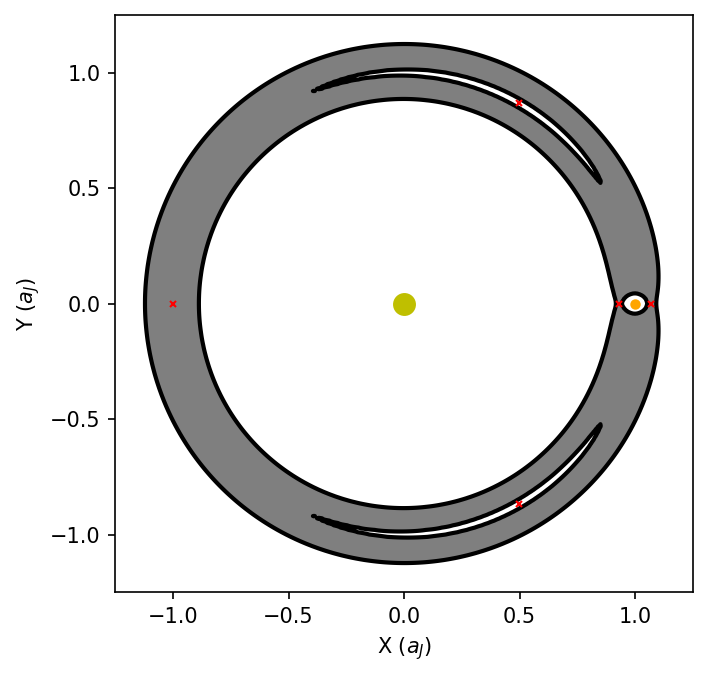

In [5]:
cmap = cm.gnuplot
my_cmap = cm.get_cmap(cmap)
norm = colors.Normalize(0,1)
cmmapable = cm.ScalarMappable(norm,my_cmap)
cmmapable.set_array(range(0,1))
my_cmap.set_under('k')

x_color='r'
ms = 3

X = np.arange(-1.5,1.5,0.01)
Y = np.arange(-1.5,1.5,0.01)
xx,yy = np.meshgrid(X,Y)
Z = pseudo_pot(xx,yy,mu)

fig = plt.figure(1,figsize=(5,5),dpi=150)
ax = fig.add_subplot(111,aspect='equal')

ax.contourf(X,Y,Z,levels=[3,C1],cmap=cm.binary)
ax.contour(X,Y,Z,levels=[3,C1],colors='k',linestyles='solid',linewidths=2)

ax.plot(-(1-mu),0,'y.',ms=20)
ax.plot(mu,0,'.',color='orange',ms=8)
ax.plot(1-L1,0,'x',color=x_color,ms=ms)
ax.plot(1+L1,0,'x',color=x_color,ms=ms)
ax.plot(L3,0,'x',color=x_color,ms=ms)
ax.plot(0.5 - alpha,np.sqrt(3.)/2.,'x',color=x_color,ms=ms) # for $mu <= 0.5 this should be 0.5 - mu
ax.plot(0.5 - alpha,-np.sqrt(3.)/2.,'x',color=x_color,ms=ms)

ax.set_xlim(-1.25,1.25)
ax.set_ylim(-1.25,1.25)
ax.set_ylabel("Y $(a_J)$")
ax.set_xlabel("X $(a_J)$");

## Define the ZVC parameters for the Earth-Moon system

The following code defines a function called `potential(x, y)`. This function calculates the effective potential energy (U) at a given point (x, y) in a rotating coordinate system, typically used in the context of the restricted three-body problem. It uses the mass ratio mu (which is assumed to be defined elsewhere in the notebook) to compute the distances to two primary bodies (`ro` and `r1`) and then combines these with the centrifugal potential term to return twice the pseudopotential.

In [6]:
def potential(x,y):
	ro = np.sqrt((x+mu)**2+y**2)
	r1 = np.sqrt((x-(1.-mu))**2+y**2)
	U = (1.-mu)/ro + mu/r1 + (x**2+y**2)/2.
	return 2.*U

The following code initializes parameters for a celestial system, specifically an Earth-Moon system, where mu is set to the mass ratio of the Moon relative to the Earth-Moon system's total mass. It then creates a grid of x and y coordinates (`xi`, `yi`, `xx`, `yy`) to define the spatial region for calculations. The potential function (defined elsewhere) is called with this grid to compute zi, which represents the potential energy at each point in the grid. Finally, it calculates the approximate positions of the Lagrange points L1, L3, and L4 based on the mass ratio mu, and sets up some visual styling parameters like col for color, mark for marker style, and ms for marker size, which will be used for plotting.

In [7]:
mu = 1./81.
xi = np.arange(-2.,2.,0.001)
yi = np.arange(-2.,2.,0.001)
xx,yy = np.meshgrid(xi,yi)
zi = potential(xx,yy)
L1 = (mu/3.)**(1./3)
L3 = -(1.+(5*mu/12.))
L4 = 0.5-mu
col = 'k'
mark = '.'
ms = 15

## Plot the ZVC's of the Earth-Moon system for many values of the Jacobi constant ($C_j$ = 3, 3.05, 3.1, 3.15)

The following code generates a visualization of the Earth-Moon system's Zero Velocity Contours and marks its five Lagrange points. It starts by creating a matplotlib figure and axis with an equal aspect ratio. It then plots contour lines of the potential energy (`zi`) using values between 3 and 3.2, which represent different Zero Velocity Contours. A dashed line indicates the x-axis. The code then meticulously plots and labels each of the five Lagrange points (L1, L2, L3, L4, L5) using previously calculated coordinates. It also draws dashed lines connecting the L4 and L5 points to the primary bodies, forming a triangular shape. The Earth and Moon are plotted as blue circular markers. Finally, it adds a legend, sets the x and y axis limits, and hides the axis ticks and labels for a cleaner astronomical visualization.

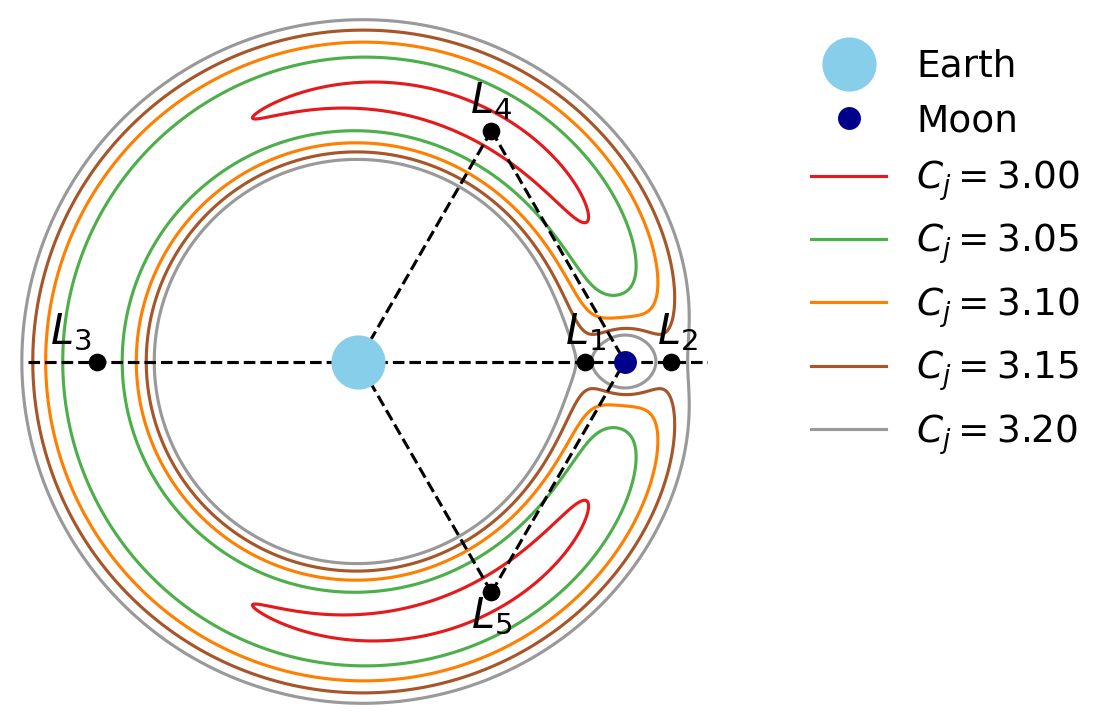

In [8]:
fig  = plt.figure(figsize=(6,6),dpi=150)
ax = fig.add_subplot(111,aspect='equal')

#ax.plot((1.-mu)*np.cos(theta),(1.-mu)*np.sin(theta),'k-',lw=2)
CS = ax.contour(xi,yi,zi,np.arange(3,3.2,0.05),cmap=plt.cm.Set1)
ax.plot([-1.25,1.35],[0,0],'k--',ms=1.5)
ax.plot(1.-L1,0,marker=mark,color=col,ms=ms)
ax.text(1.-L1,0.065,'$L_1$',fontsize=20,horizontalalignment='center')
ax.plot(1.+L1,0,marker=mark,color=col,ms=ms)
ax.text(1.+L1+0.025,0.065,'$L_2$',fontsize=20,horizontalalignment='center')
ax.plot(L3+mu,0,marker=mark,color=col,ms=ms)
ax.text(L3-0.1+mu,0.065,'$L_3$',fontsize=20,horizontalalignment='center')
ax.plot(L4,np.sqrt(3)/2.,marker=mark,color=col,ms=ms)
ax.text(L4,np.sqrt(3)/2.+0.065,'$L_4$',fontsize=20,horizontalalignment='center')
ax.plot(L4,-np.sqrt(3)/2.,marker=mark,color=col,ms=ms)
ax.text(L4,-np.sqrt(3)/2.-0.135,'$L_5$',fontsize=20,horizontalalignment='center')

ax.plot([L4,-mu],[np.sqrt(3.)/2.,0],'k--',lw=1.5)
ax.plot([L4,1.-mu],[np.sqrt(3.)/2.,0],'k--',lw=1.5)
ax.plot([L4,-mu],[-np.sqrt(3.)/2.,0],'k--',lw=1.5)
ax.plot([L4,1.-mu],[-np.sqrt(3.)/2.,0],'k--',lw=1.5)

ax.plot(-mu,0,'.',mfc='skyblue',mec='skyblue',ms=50,label='Earth')
ax.plot(1.-mu,0,'.',mfc='darkblue',mec='darkblue',ms=20,label='Moon')
#ax.plot(0,0,'kx',ms=5,label="CoM")

# Add individual legend entries for each contour level
contour_levels = np.arange(3, 3.2, 0.05)
colors_for_legend = [CS.cmap(CS.norm(level)) for level in contour_levels]
for i, level in enumerate(contour_levels):
    ax.plot([], [], color=colors_for_legend[i], label=f'$C_j = {level:.2f}$', linestyle='-')

ax.legend(bbox_to_anchor=(1.1, .5, .3, .5),numpoints=1,fontsize=18,frameon=False)
ax.set_xlim(-1.3,1.3)
ax.set_ylim(-1.3,1.3)
ax.axis('off');

## Plot the ZVC's of the Sun-Earth system for many values of the Jacobi constant

The following code defines a function called Jacobi_const(x, y, xo, yo, x1, y1) that calculates the Jacobi constant, which is an integral of motion in the restricted three-body problem. It represents the total energy in a rotating frame of reference.

ro and r1 calculate the distances from a test particle at (x, y) to the two primary bodies (e.g., Sun and Earth) located at (xo, yo) and (x1, y1) respectively.
phi computes an intermediate potential value based on these distances and the mass ratio mu.
Finally, the function returns 2*phi, which is the Jacobi constant.

In [9]:
def Jacobi_const(x,y,xo,yo,x1,y1):
    ro = np.sqrt((x-xo)**2+(y-yo)**2) #distance from particle to the Sun
    r1 = np.sqrt((x-x1)**2+(y-y1)**2) #distance from particle to the Earth
    phi = (1.-mu)*(ro**2/2. + 1./ro) + mu*(r1**2/2. + 1./r1)
    return 2*phi

The following code sets up parameters for a Sun-Earth system within the context of the restricted three-body problem and calculates a set of Jacobi constant levels (`Z_levels`) to be used for plotting Zero Velocity Contours.

It initializes the gravitational constant G, the masses of the Sun (`M_sun`) and Earth (`M_E`), and then calculates the mass ratio mu (Earth's mass relative to the total system mass). It calculates the R_H, which is the Hill radius, a measure of the gravitational sphere of influence of the Earth. It defines the positions of the Earth (`x_E`, `y_E`) and Sun (`x_S`, `y_S`) in the rotating coordinate system. It then generates a series of radial distances in `r_levels`. These distances are used to calculate corresponding `Z_levels` (Jacobi constants) by calling the Jacobi_const function (defined in a previous cell) at these specific points on the x-axis, and one additional point related to the L4/L5 Lagrange points. These `Z_levels` represent the values of the Jacobi constant for which contours will be drawn, effectively showing boundaries of permissible motion for a test particle. Finally, it sorts these `Z_levels` in ascending order and prints them to the console.

In [10]:
G = 4*np.pi**2
M_sun = 1 # 1 solar mass
M_E = 3.0035e-6 #mass of Earth in M_sun
mu = M_E/(M_E+M_sun) # mass ratio
R_H = (mu/3)**(1./3.) # Hill radius
x_E, y_E = (1-mu), 0
x_S, y_S = -mu, 0

r_levels = [0.3,0.6,0.9]
for i in range(1,10):
    r_levels.append(1+i*0.25*R_H)
n_lev = len(r_levels)
Z_levels = np.zeros(n_lev+1)
for r in range(0,n_lev):
    Z_levels[r] = Jacobi_const(r_levels[r],0,x_S,y_S,x_E,y_E)
Z_levels[-1] = Jacobi_const(0.5-x_E,np.sqrt(3)/2,x_S,y_S,x_E,y_E)
Z_levels.sort()
print(Z_levels)

[3.00000347 3.0008897  3.00093672 3.00095947 3.00106035 3.00124328
 3.0012661  3.00147675 3.00175584 3.00240875 3.03227121 3.69332466
 6.75659148]


The following code generates a visualization of the Sun-Earth system's Zero Velocity Contours (ZVCs), including a zoomed-in inset around the Earth. It sets up the main plot and an inset subplot, then plots the Sun and Earth, along with other reference points. It calculates and displays ZVCs for both the main view (in Astronomical Units) and the inset view (scaled by the Hill radius), and finally, labels the axes for clarity.

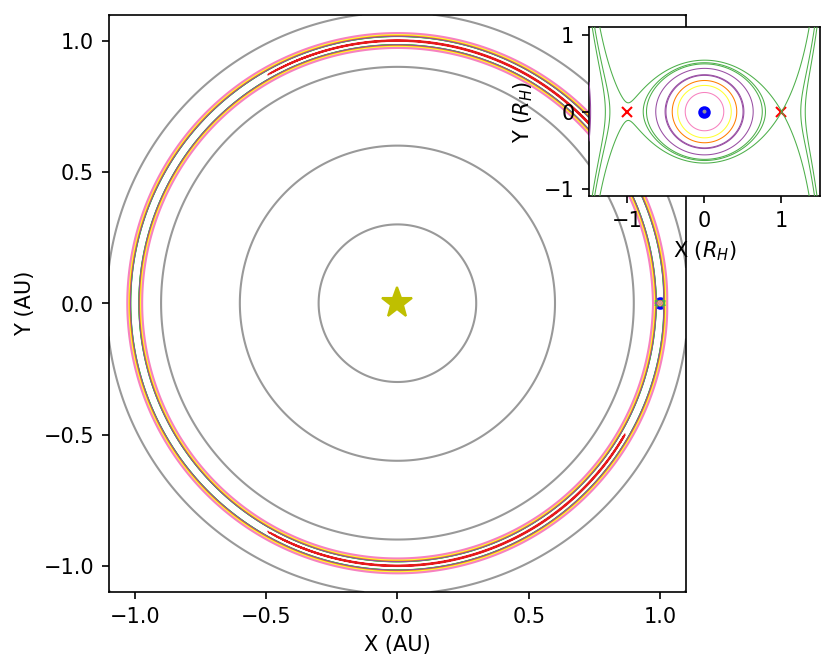

In [11]:
fig = plt.figure(figsize=(5,5),dpi=150)
ax = fig.add_subplot(111, aspect='equal')
axins = inset_axes(ax, width="40%", height="40%",bbox_to_anchor=(0.25, 0.05, 1, 1), bbox_transform=ax.transAxes)
axins.set_aspect('equal')

ax.plot(x_S,y_S,'y*',ms=15)
ax.plot(x_E,y_E,'b.',ms=10)
axins.plot(0,0,'b.',ms=10)
axins.plot(1,0,'rx',ms=5)
axins.plot(-1,0,'rx',ms=5)

xi = np.arange(x_E-1.5*R_H,x_E+1.5*R_H,0.01*R_H)
yi = np.arange(y_E-1.1*R_H,y_E+1.1*R_H,0.01*R_H)
xx,yy = np.meshgrid(xi,yi)
Z = Jacobi_const(xx,yy,x_S,y_S,x_E,y_E)

vmin, vmax = 3, 3.003
my_cmap = plt.colormaps['Set1']
norm = colors.Normalize(vmin=vmin, vmax=vmax)
#my_cmap.set_under('k')

ax.contour(xx,yy,Z, levels=Z_levels,zorder=5,cmap=my_cmap,norm=norm)
axins.contour((xx-x_E)/R_H,yy/R_H,Z, levels=Z_levels,zorder=5,cmap=my_cmap,norm=norm,linewidths=0.5)
axins.set_xlabel("X ($R_H$)")
axins.set_ylabel("Y ($R_H$)")

xi = np.arange(-1.1,1.1,0.001)
yi = np.arange(-1.1,1.1,0.001)
xx,yy = np.meshgrid (xi,yi)
Z = Jacobi_const(xx,yy,x_S,y_S,x_E,y_E)
ax.contour(xx,yy,Z, levels=Z_levels,zorder=2,cmap=my_cmap,norm=norm,linewidths=1)
ax.set_ylabel("Y (AU)")
ax.set_xlabel("X (AU)")
ax.set_yticks(np.arange(-1,1.5,0.5))
ax.set_xticks(np.arange(-1,1.5,0.5));

## Mutual Hill Radius and Scaling
---

The following code initializes several parameters for a multi-body celestial system, often used in studies of planetary dynamics or exoplanet systems.

`M_star` represents the mass of the central star, set to 1 solar mass. `m_1` represents the mass of the first planet (e.g., Jupiter), given in solar masses. `m_2` represents the mass of the second planet (e.g., Earth), also given in solar masses. `a_1` represents the semimajor axis of the inner orbit, normalized to 1 Astronomical Unit (AU). The variable `X` calculates a critical distance or scaling factor. It's derived from the masses of the central star and the two planets, related to the concept of mutual Hill radius or a similar stability criterion for orbital interactions. `delta_H` is a constant factor, set to 5, which is a parameter used in further calculations, related to orbital separation criteria or stability thresholds for planets in a multi-planet system.

In [12]:
M_star = 1 #central mass in M_sun
m_1 = 9.54e-4 #Jupiter mass in M_sun
m_2 = 3.0035e-6 #Earth mass in M_sun

a_1 = 1 #inner orbit in normalized units (1 AU)
X = 0.5*((m_1+m_2)/(3*(M_star+m_1)))**(1./3.)
delta_H = 5

The following code defines two functions crucial for celestial mechanics:

`calc_orbit(a, e, omg)` calculates the Cartesian (x, y) coordinates for an elliptical orbit given its orbital elements: `a`, the semi-major axis, `e` the eccentricity, and `omg`, the argument of periapsis (the angle from the x-axis to the periapsis). It generates points along the orbit using the true anomaly (`f`) and the polar equation of an ellipse, then converts these polar coordinates to Cartesian coordinates.

`get_semi(delta_H, a_j, X, k, j) `calculates the semi-major axis (`a_k`) for a '`k`'-th orbit, based on the semi-major axis of a '`j`'-th orbit (`a_j`) and other parameters. This type of calculation is often used in studies of orbital stability and planet packing, where `delta_H` and `X` represent factors related to the mutual Hill radius or orbital spacing criteria. The (k-j) exponent suggests a geometric progression or scaling relationship for orbital distances in a multi-planet system.

In [13]:
def calc_orbit(a,e,omg):
    #calculate Cartesian orbit given a, e, omega
    f = np.arange(0,2*np.pi,0.01)
    r = a*(1-e**2)/(1.+e*np.cos(f))
    return (r*np.cos(omg+f), r*np.sin(omg+f))

def get_semi(delta_H,a_j,X,k,j):
    #calculate a_k given a_j
    return a_j*((1+delta_H*X)/(1-delta_H*X))**(k-j)

The following code calculates the semi-major axis for a second planet (`a_2`) using the `get_semi` function, likely based on orbital spacing criteria. It then uses the calc_orbit function to determine the Cartesian coordinates (`x_1`, `y_1` and `x_2`, `y_2`) for two planets on circular orbits, with the second planet initially positioned opposite the first.

In [14]:
a_2 = get_semi(delta_H,a_1,X,2,1)
x_1,y_1 = calc_orbit(a_1,0,0)
x_2,y_2 = calc_orbit(a_2,0,np.pi)

The following code generates a visualization of the two planetary orbits around the central star, using an inner Jupiter-mass planet and outer Earth-mass planet separated by
$5 R_{H,m}$, mutual Hill radii, for a 2-planet system.

It creates a new `matplotlib` figure and a single subplot (`ax`) for the plot. `ax.plot(0,0,'.',color='y',ms=20)` plots a large yellow dot at the origin (0,0), representing the central star. `ax.plot(x_1,y_1,'k-',lw=2)` draws the orbit of the first planet in black, and `ax.plot(x_1[0],y_1[0],'c.',ms=10)` marks its initial position with a cyan dot. `ax.plot(x_2,y_2,'-',color='gray',lw=2)` draws the orbit of the second planet in gray, and `ax.plot(x_2[0],y_2[0],'b.',ms=10)` marks its initial position with a blue dot. Finally, it labels the X and Y axes as "X (AU)" and "Y (AU)" respectively, indicating that the plot uses Astronomical Units for its scale.

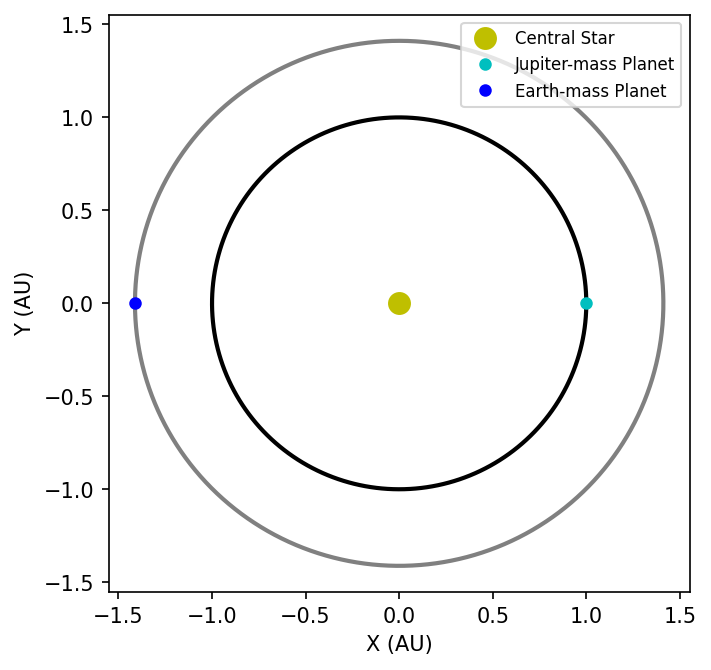

In [15]:
fig = plt.figure(figsize=(5,5),dpi=150)
ax = fig.add_subplot(111)

ax.plot(0,0,'.',color='y',ms=20, label='Central Star')
ax.plot(x_1,y_1,'k-',lw=2)
ax.plot(x_1[0],y_1[0],'c.',ms=10, label='Jupiter-mass Planet')
ax.plot(x_2,y_2,'-',color='gray',lw=2)
ax.plot(x_2[0],y_2[0],'b.',ms=10, label='Earth-mass Planet')

ax.set_xlabel("X (AU)")
ax.set_ylabel("Y (AU)")

plt.legend(fontsize=8,loc='upper right')

## The Golden Ratio to debias the initial orbital phase
---

The following code initializes various mass parameters for a multi-body celestial system and defines the golden ratio. It then sets up a list of masses for a hypothetical system containing three Earth-mass planets and one Jupiter-mass planet.

In [16]:
M_sun = 1 #solar mass in M_sun
M_E = 3.0035e-6 #Earth mass in M_sun
M_J = 9.54e-4 #Jupiter mass in M_sun
phi = (1+np.sqrt(5))/2. # golden ratio

M_star = M_sun
m_1 = M_E
m_2 = M_E
m_3 = M_E
m_4 = M_J
Mass = [M_star,m_1,m_2,m_3,m_4]

The `get_semi` function calculates the semi-major axis for a k-th orbit (`a_k`) based on a j-th reference orbit (`a_j`) and system masses. It's used to model orbital spacing in multi-planet systems, incorporating a `delta_H` scaling factor related to the mutual Hill radius and a term X derived from the masses and total mass `Mass[:k]` up to the k-th planet.

The `get_TrueAnomaly` function calculates the true anomaly (angle) for the j-th planet, using the golden ratio (`phi`) to generate an initial orbital phase that helps to debias initial orbital phases.

In [17]:
def get_semi(delta_H,a_j,k,j):
    #calculate a_k given a_j (k>j)
    M_tot = np.sum(Mass[:k])
    X = 0.5*((Mass[j]+Mass[k])/(3*M_tot))**(1./3.)
    return a_j*((1+delta_H*X)/(1-delta_H*X))**(k-j)

def get_TrueAnomaly(j):
    return (j*phi*2*np.pi) % (2*np.pi)

The `simulation` function sets up and runs an N-body simulation using the REBOUND library. It configures the integrator, units, and time step, adds a central star and four planets with their respective masses, semi-major axes, eccentricities, and initial true anomalies (calculated using `get_TrueAnomaly`). It then moves the system to its center of mass, sets up an archive for output, and integrates the system for a specified time scale.

In [24]:
def simulation(tscale,fname,out_step):
    sim = rebound.Simulation()
    sim.integrator = 'ias15'
    sim.units = ('yr', 'AU','Msun')
    sim.dt = 0.05*T_1

    sim.add(m=M_star)
    for j in range(1,5):
        f_j = get_TrueAnomaly(j)
        sim.add(m=Mass[j],a=semi[j],e=ecc[j],f=f_j)
    sim.move_to_com()

    #sim.automateSimulationArchive(fname,step=out_step,deletefile=True)
    sim.save_to_file(fname,step=out_step,delete_file=True)
    sim.integrate(tscale)

The following code initializes critical orbital parameters for a multi-planet system before running a simulation. It sets the semi-major axis for the innermost orbit (`a_1`), calculates a mass ratio (`mu_1`), and determines the orbital period of the first planet (`T_1`). It then uses a loop and the `get_semi` function to define the semi-major axes for three planets, based on a `delta_H` scaling factor, and adds a fixed semi-major axis for a fourth planet. Finally, it initializes an array of eccentricities, setting the outermost planet's eccentricity to 0.05 while the others remain circular.

In [25]:
a_1 = 1 #innermost orbit starting a 1 AU
mu_1 = (m_1/M_star)**(1./3.)
T_1 = np.sqrt(a_1**2/M_star) #innermost orbital period in years
delta_H = 10
semi = [0,a_1]
for k in range(2,4):
    semi.append(get_semi(delta_H,a_1,k,1))
semi.append(5.2)
print(semi[1:])
ecc = np.zeros(5)
ecc[-1] = 0.05

[1, np.float64(1.1345183686262765), np.float64(1.2871316026156066), 5.2]


The following code defines `output_bin` as the filename where the simulation data will be saved (e.g., "SSanalog_test.bin"). Then, output_steps sets the interval at which the simulation data will be saved to that file. Finally, it calls the simulation function, which was defined earlier, passing in a total simulation time of 500 years (which equates 500 orbits of the innermost planet), the `output_bin` filename, and the `output_steps` interval. This effectively starts the N-body simulation with the specified parameters and enables periodic saving of its state.

In [26]:
output_bin = "SSanalog_test.bin"
output_steps = 5
simulation(500,output_bin,output_steps)

The following code visualizes the N-body simulation results. It loads the simulation data from `output_bin` into a `rebound.Simulationarchive`. It then creates a main plot and a zoomed-in inset, both showing the central star. The code iterates through each snapshot in the archive, extracts the x and y coordinates of the planets, and shifts the system to the center-of-mass frame. Finally, it plots the trajectories of the four planets, with initial positions marked, using different colors, and sets axis labels for clarity. The inset plot focuses on the inner planets. The inner planets are Earth-mass while the outer planet is Jupiter-mass.

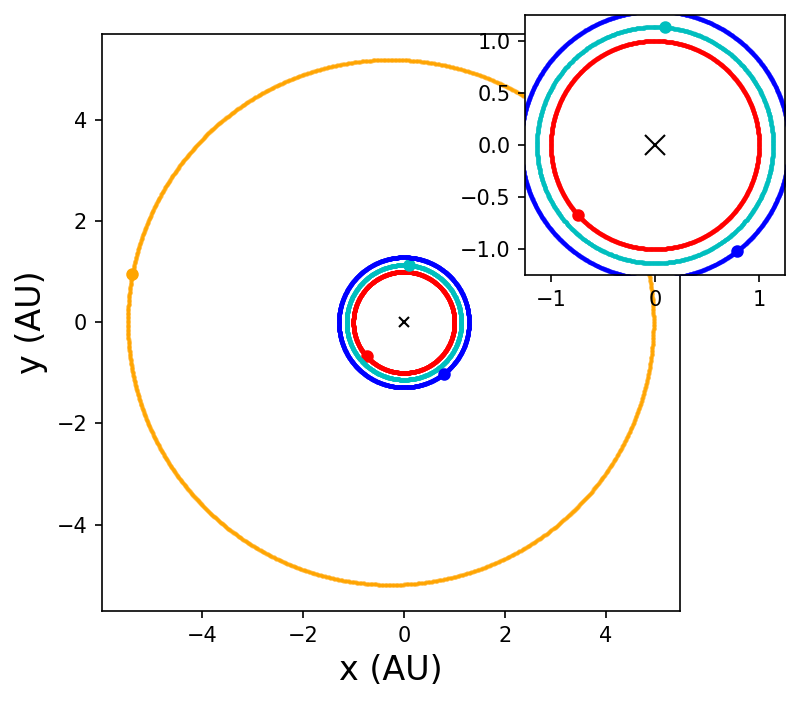

In [35]:
#plot the simulation
#sa = rebound.SimulationArchive(output_bin)
sa = rebound.Simulationarchive(output_bin)

fig = plt.figure(figsize=(5,5),dpi=150)
ax = fig.add_subplot(111)
ax.set_aspect('equal')
axins = inset_axes(ax, width="150%", height="150%", bbox_to_anchor=(.9, .7, .3, .5), bbox_transform=ax.transAxes)
axins.set_aspect('equal')

ax.plot(0,0,'kx',ms=5)
xy_coords = np.zeros((len(sa),2*4))
for s in range(0,len(sa)):
    sim = sa[s] #iterate through each snapshot in sa
    ps = sim.particles #intermediate object to simplify the referencing
    sim.move_to_hel() #shift to center-of-mass coordinates
    for p in range(0,len(ps)-1):
        #Cart = np.array([ps[p].x, ps[p].y, ps[p].z])
        #rot_xy = Rot(-ps[1].Omega,-ps[1].inc,Cart)
        xy_coords[s,2*p] = ps[p+1].x
        xy_coords[s,2*p+1] = ps[p+1].y

color = ['r','c','b','orange']
for p in range(0,4):
    ax.plot(xy_coords[:,2*p],xy_coords[:,2*p+1],'.',color=color[p],ms=2,alpha=0.3)
    ax.plot(xy_coords[0,2*p],xy_coords[0,2*p+1],'.',color=color[p],ms=10)
    if p < 3:
        axins.plot(xy_coords[:,2*p],xy_coords[:,2*p+1],'.',color=color[p],ms=2,alpha=0.3)
        axins.plot(xy_coords[0,2*p],xy_coords[0,2*p+1],'.',color=color[p],ms=10)
axins.plot(0,0,'kx',ms=10)
axins.set_xlim(-1.25,1.25)
axins.set_ylim(-1.25,1.25)

ax.set_xlabel("x (AU)",fontsize=16)
ax.set_ylabel("y (AU)",fontsize=16);

The next view plots only the magnitude $e_P$ and direction $\omega_P$ for the eccentricity vector of each terrestrial planet. Along with the vector components of the respective eccentricity vectors.

The strength of gravitational perturbation for each terrestrial planet is modulated by its distance from the outer Jupiter-mass planet. Therefore, the eccentricity for each of the terrestrial planets should respond to the gravity of the Jupiter-mass planet and to the smaller perturbations from its neighbor planets.

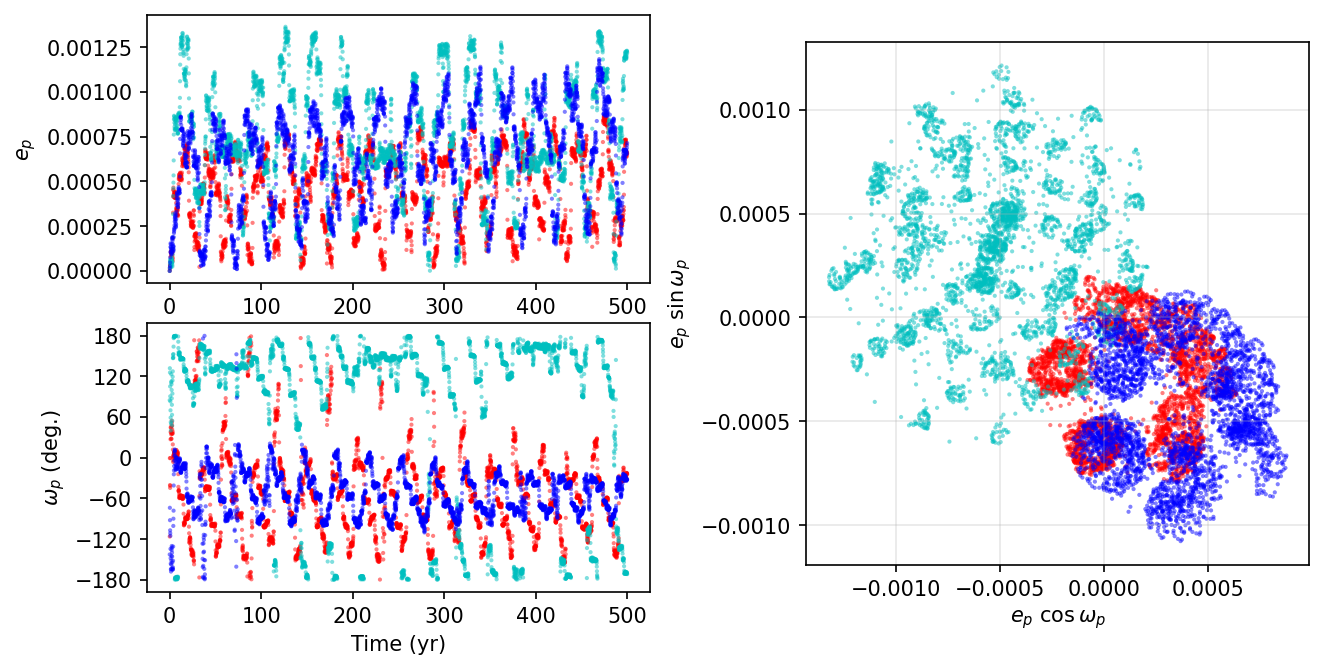

In [39]:
#plot the simulation
sa = rebound.Simulationarchive(output_bin)

fig = plt.figure(figsize=(10,5),dpi=150)
gs = GridSpec(2, 4, figure=fig,wspace=0.9,hspace=0.15)
ax1 = fig.add_subplot(gs[:1,:2])
ax2 = fig.add_subplot(gs[1:,:2])
ax3 = fig.add_subplot(gs[:,2:],aspect='equal')

time = np.zeros(len(sa))
pl_orb = np.zeros((len(sa),4,3))
for s in range(0,len(sa)):
    sim = sa[s] #iterate through each snapshot in sa
    ps = sim.particles #intermediate object to simplify the referencing
    sim.move_to_hel() #shift to center-of-mass coordinates
    time[s] = sim.t
    for p in range(0,len(ps)-1):
        pl_orb[s,p,:] = [ps[p+1].a,ps[p+1].e,ps[p+1].omega]

color = ['r','c','b','orange']
for p in range(0,3):
    e_p, omg_p = pl_orb[:,p,1], pl_orb[:,p,2]
    omg_p[omg_p>np.pi] -= 2*np.pi
    ax1.scatter(time,e_p,marker='o',color=color[p],edgecolor='None',s=4,alpha=0.5)
    ax2.scatter(time,np.degrees(omg_p),marker='o',c=color[p],edgecolor='None',s=4,alpha=0.5)
    ax3.scatter(e_p*np.cos(omg_p),e_p*np.sin(omg_p),marker='o',c=color[p],edgecolor='None',s=4,alpha=0.5)
ax1.set_ylabel(r"$e_p$")
ax2.set_ylabel(r"$\omega_p$ (deg.)")
ax3.set_ylabel(r"$e_p\ \sin{\omega_p}$")

ax1.set_xlabel("Time (yr)")
ax2.set_xlabel("Time (yr)")
ax3.set_xlabel(r"$e_p\ \cos{\omega_p}$")
ax2.set_yticks(np.arange(-180,180+60,60))
ax3.grid(True,alpha=0.3);